# Sentiment Analysis

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd

#Read the data 
df=pd.read_csv("Reviews.csv",nrows=100)

#Look % Top row
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
#looking at summary
df.Summary.head()

0    Good Quality Dog Food
1        Not as Advertised
2    "Delight" says it all
3           Cough Medicine
4              Great taffy
Name: Summary, dtype: str

In [3]:
#Looking at the decription of the reviews
df.Text.head()

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
Name: Text, dtype: str

In [4]:
#Import libraries
from nltk.corpus import stopwords
from textblob import TextBlob
from textblob import Word

# Lower casting and removing punctuations

In [5]:
df['Text'] = df['Text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
df['Text']=df['Text'].str.replace('[^\w\s]','')
import nltk
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
nltk.download('punkt',quiet=True)
#Removal of stop words
stop=stopwords.words('english')
df['Text']=df['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))

# Spelling correction
df['Text']=df['Text'].apply(lambda x: str(TextBlob(x).correct()))

#Lemmatization
df['Text']=df['Text'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

df.Text.head(5)

0    bought several vitality canned dog food produc...
1    product arrived labelled lumbo halted peanuts....
2    connection around centuries. light, pillow cit...
3    looking secret ingredient robitussin believe f...
4    great staff great price. wide assortment mummy...
Name: Text, dtype: str

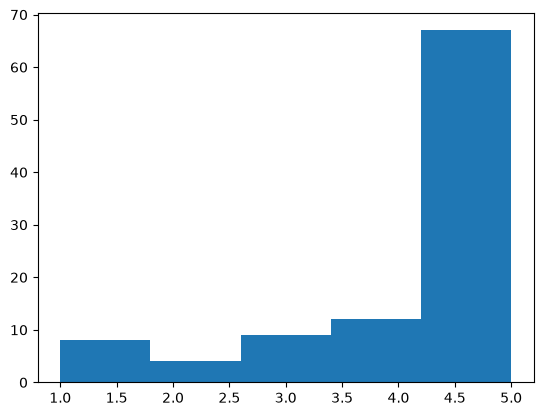

Score
1     8
2     4
3     9
4    12
5    67
Name: Id, dtype: int64


In [16]:
# Create a new data frame “reviews” to perform exploratory data analysis upon␣ →that 
reviews = df # Dropping null values 
reviews.dropna(inplace=True) # The histogram reveals this dataset is highly unbalanced towards high rating. 
reviews.Score.hist(bins=5,grid=False) 
plt.show() 
print(reviews.groupby('Score').count().Id)

In [18]:
#Tomake itbalanced data,wesampled each score bythelowest n-count from␣ →above.(i.e.29743reviewsscored as '2')
score_1= reviews[reviews['Score'] ==1].sample(n=4)
score_2= reviews[reviews['Score'] ==2].sample(n=4)
score_3= reviews[reviews['Score'] ==3].sample(n=4)
score_4= reviews[reviews['Score'] ==4].sample(n=4)
score_5= reviews[reviews['Score'] ==5].sample(n=4)
#Here werecreatea'balanced' dataset. 
reviews_sample= pd.concat([score_1,score_2,score_3,score_4,score_5],axis=0) 
reviews_sample.reset_index(drop=True,inplace=True) 
#Printingcountby 'Score'tocheckdatasetis now balanced.
print(reviews_sample.groupby('Score').count().Id)

Score
1    4
2    4
3    4
4    4
5    4
Name: Id, dtype: int64


## VADER Sentiment Analysis

In [6]:
!pip install vaderSentiment

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Generating sentiment for all the sentence present in the dataset
emptyline=[]
for row in df['Text']:
    vs=analyzer.polarity_scores(row)
    emptyline.append(vs)

In [8]:
#Creating new dataframe with sentiments 
df_sentiments=pd.DataFrame(emptyline)
df_sentiments.head(5)

,neg,neu,pos,compound
0,0.000,0.517,0.483,0.9413
1,0.258,0.644,0.099,-0.5719
2,0.126,0.623,0.250,0.7880
3,0.000,0.868,0.132,0.4404
4,0.000,0.455,0.545,0.9186


## Compound score is the metric that calculates the sentiment score(-1 to 1)
- positive > 0.05
- neutral > -0.05 and <0.05
- negative <= -0.05

In [9]:
df_c = pd.concat([df.reset_index(drop=True), df_sentiments], axis=1)
df_c.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,neg,neu,pos,compound
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,bought several vitality canned dog food produc...,0.000,0.517,0.483,0.9413
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labelled lumbo halted peanuts....,0.258,0.644,0.099,-0.5719
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","connection around centuries. light, pillow cit...",0.126,0.623,0.250,0.7880


In [10]:
# Convert scores into postive and negative sentiments using some threshold
df_c['Sentiment']=np.where(df_c['compound']>=0 , 'Positive', 'Negative')
df_c.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,neg,neu,pos,compound,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,bought several vitality canned dog food produc...,0.000,0.517,0.483,0.9413,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labelled lumbo halted peanuts....,0.258,0.644,0.099,-0.5719,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","connection around centuries. light, pillow cit...",0.126,0.623,0.250,0.7880,Positive


In [11]:
df_c[['Text','Sentiment']]

,Text,Sentiment
0,bought several vitality canned dog food produc...,Positive
1,product arrived labelled lumbo halted peanuts....,Negative
2,"connection around centuries. light, pillow cit...",Positive
3,looking secret ingredient robitussin believe f...,Positive
4,great staff great price. wide assortment mummy...,Positive
...,...,...
95,pleased natural balance dog food. dog issue do...,Positive
96,1-1/2 year old basenji/jack russell mix love d...,Positive
97,up experienced gallery form hotspot itching do...,Positive
98,english bulldog skin gallery summer got age 3....,Positive


In [12]:
%pip uninstall -y matplotlib

Note: you may need to restart the kernel to use updated packages.


In [13]:
%pip install --no-cache-dir matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 452.8 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 650.6 kB/s eta 0:00:14
   --- ---------------

In [14]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)
print("Matplotlib working!")

Matplotlib is building the font cache; this may take a moment.


3.11.1
Matplotlib working!
